In [1]:
# Import required libraries
import pandas as pd
import numpy as np

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rashadrmammadov/customer-churn-dataset")

print("Path to dataset files:", path)

100%|██████████| 119k/119k [00:00<00:00, 28.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rashadrmammadov/customer-churn-dataset/versions/1


In [3]:
import os

os.listdir(path)

['customer_churn_data.csv']

In [4]:
df = pd.read_csv(os.path.join(path, "customer_churn_data.csv"))

In [5]:
df.shape

(5880, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null   object 


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,2982
Yes,2898


In [ ]:
df["gender"].value_counts()

,count
gender,
Male,2950
Female,2930


In [ ]:
df["SeniorCitizen"].value_counts()

,count
SeniorCitizen,
1,2944
0,2936


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


customerID
customerID
CUST5879    1
CUST0000    1
CUST0001    1
CUST0002    1
CUST0003    1
           ..
CUST0012    1
CUST0011    1
CUST0010    1
CUST0009    1
CUST0008    1
Name: count, Length: 5880, dtype: int64

gender
gender
Male      2950
Female    2930
Name: count, dtype: int64

Partner
Partner
Yes    2995
No     2885
Name: count, dtype: int64

Dependents
Dependents
No     3004
Yes    2876
Name: count, dtype: int64

PhoneService
PhoneService
Yes    2941
No     2939
Name: count, dtype: int64

MultipleLines
MultipleLines
No phone service    2939
Yes                 1512
No                  1429
Name: count, dtype: int64

InternetService
InternetService
No             2029
DSL            1936
Fiber optic    1915
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No internet service    2029
No                     1947
Yes                    1904
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No internet service    2029
No                     1986
Yes                   

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.500680,36.549150,70.157779,2566.813165
std,0.500042,20.909674,28.804615,1910.017743
min,0.000000,1.000000,20.000000,20.030000
25%,0.000000,18.000000,45.717500,1020.217500
50%,1.000000,37.000000,70.155000,2136.445000
75%,1.000000,55.000000,95.457500,3767.665000
max,1.000000,72.000000,119.990000,8589.600000


In [ ]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,1498,1432
Male,1484,1466


In [ ]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,1056,964
One year,968,986
Two year,958,948


In [ ]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,987,949
Fiber optic,974,941
No,1021,1008


In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.522772,0.477228
One year,0.495394,0.504606
Two year,0.502623,0.497377


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    if col != "Churn":
        print(f"\n{'='*50}")
        print(f"Feature: {col}")
        print(pd.crosstab(df[col], df["Churn"]))


Feature: customerID
Churn       No  Yes
customerID         
CUST0000     1    0
CUST0001     0    1
CUST0002     0    1
CUST0003     1    0
CUST0004     0    1
...         ..  ...
CUST5875     1    0
CUST5876     0    1
CUST5877     1    0
CUST5878     1    0
CUST5879     0    1

[5880 rows x 2 columns]

Feature: gender
Churn     No   Yes
gender            
Female  1498  1432
Male    1484  1466

Feature: Partner
Churn      No   Yes
Partner            
No       1478  1407
Yes      1504  1491

Feature: Dependents
Churn         No   Yes
Dependents            
No          1525  1479
Yes         1457  1419

Feature: PhoneService
Churn           No   Yes
PhoneService            
No            1464  1475
Yes           1518  1423

Feature: MultipleLines
Churn               No   Yes
MultipleLines               
No                 737   692
No phone service  1464  1475
Yes                781   731

Feature: InternetService
Churn              No   Yes
InternetService            
DSL             

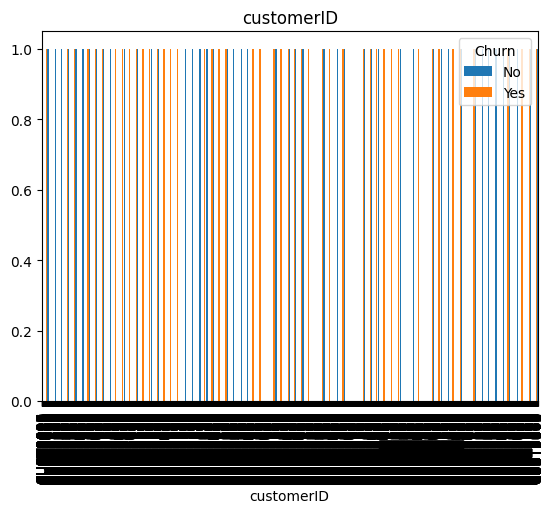

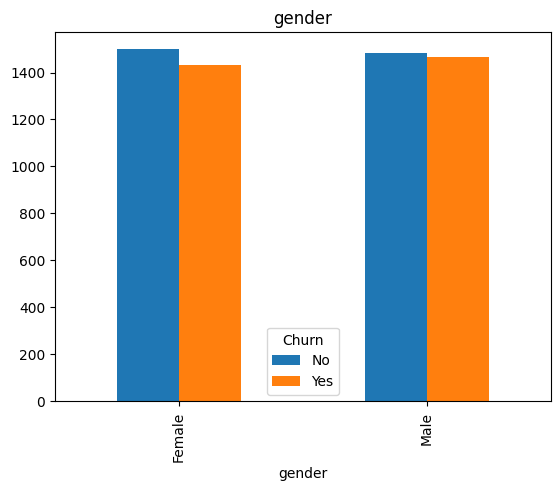

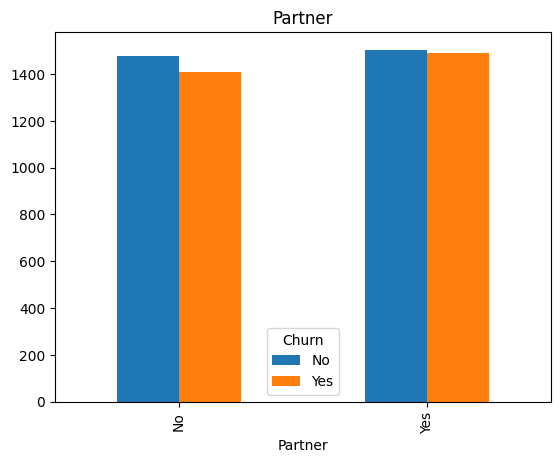

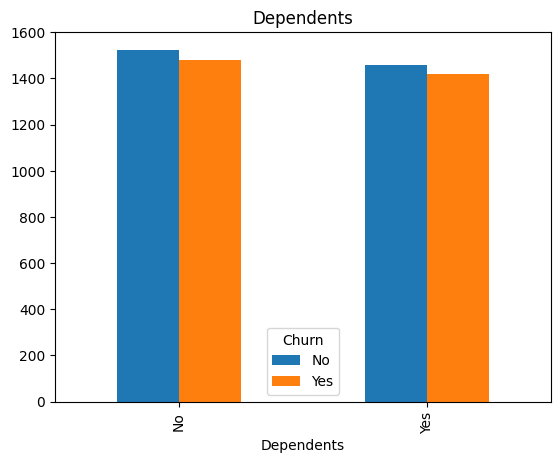

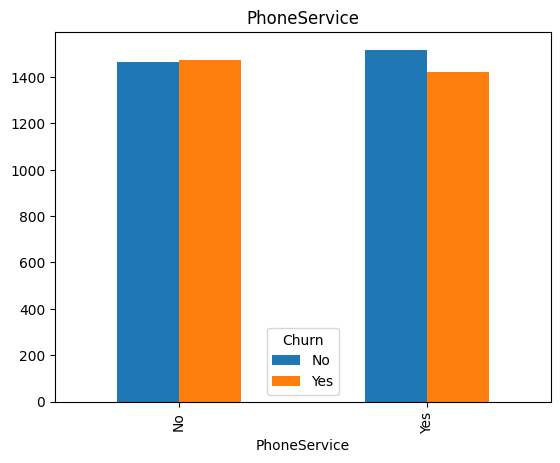

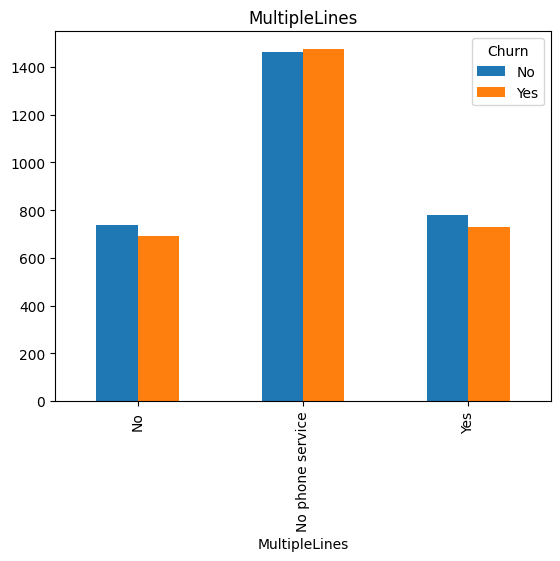

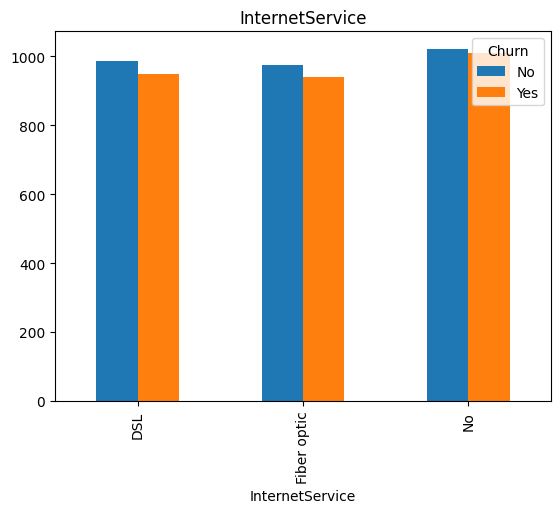

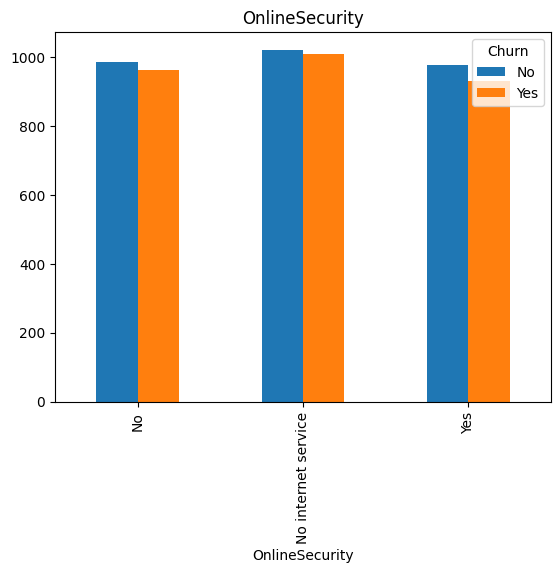

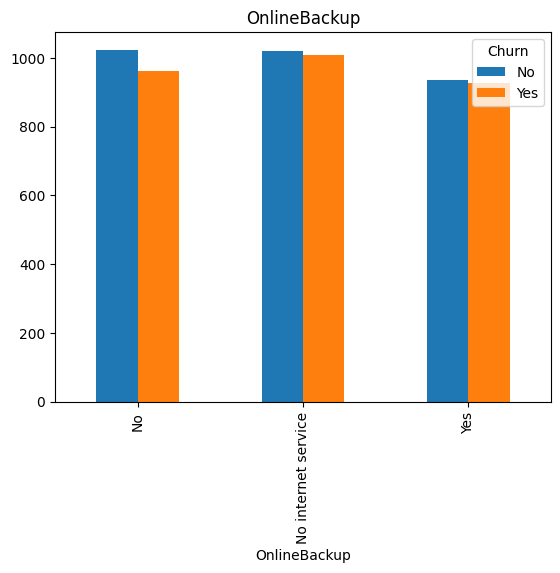

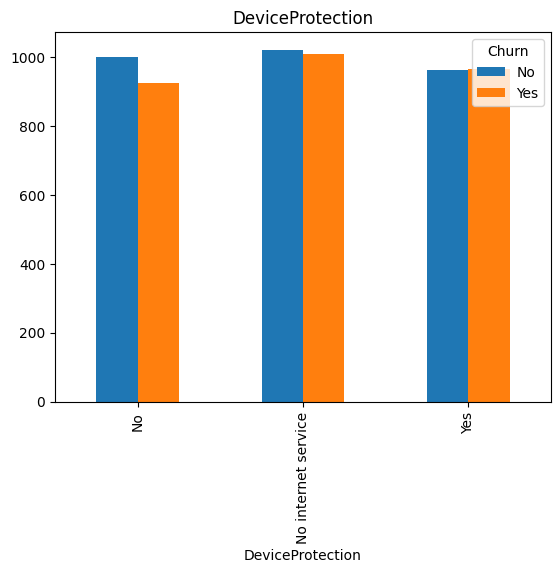

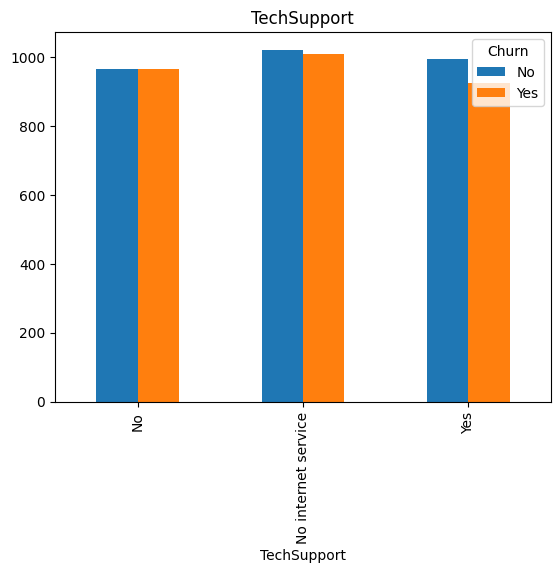

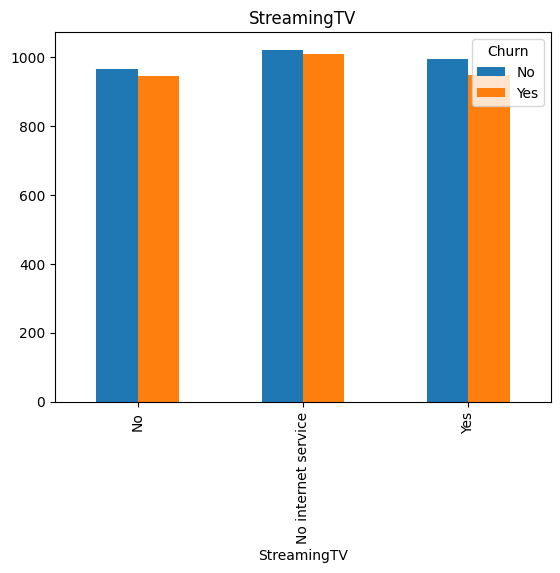

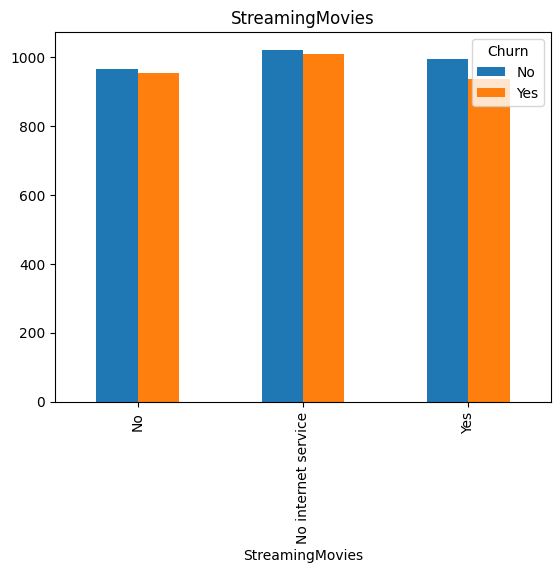

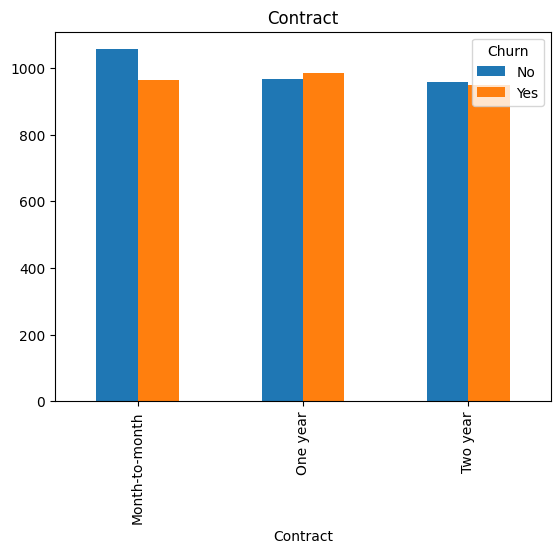

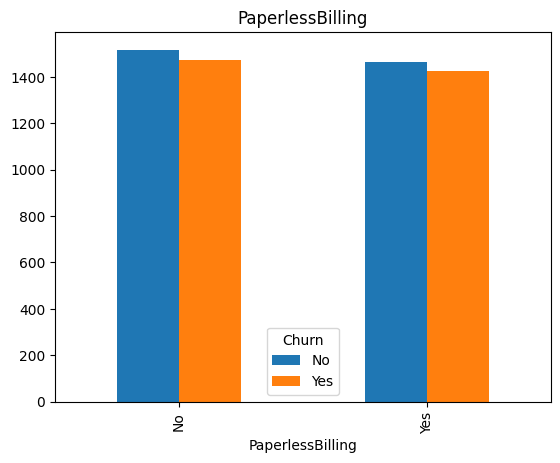

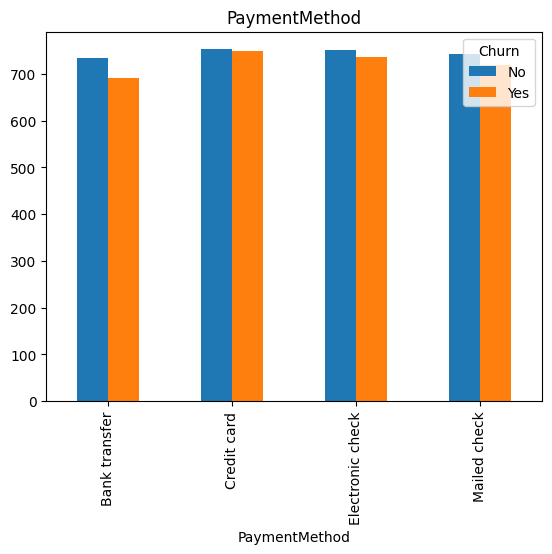

In [ ]:
import matplotlib.pyplot as plt

for col in categorical_columns:
    if col != "Churn":
        pd.crosstab(df[col], df["Churn"]).plot(kind="bar")
        plt.title(col)
        plt.show()

In [ ]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,36.371898,69.732763,2539.957689
Yes,36.731539,70.595114,2594.447060


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

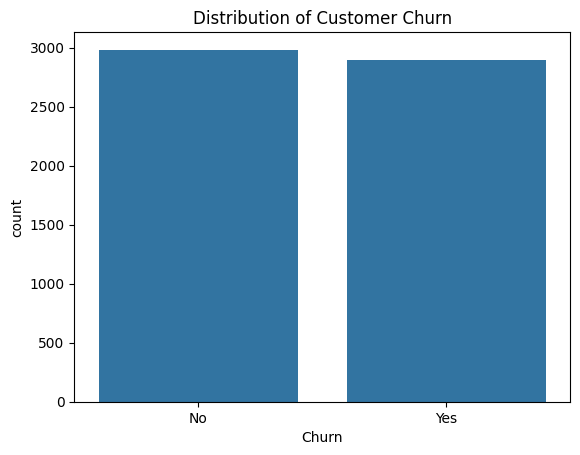

In [ ]:
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Customer Churn")
plt.show()

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

NameError: name 'sns' is not defined

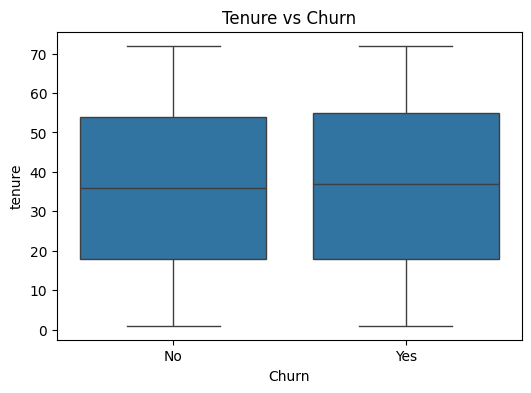

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

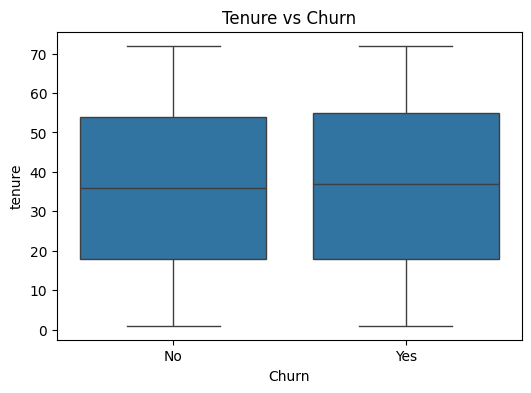

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

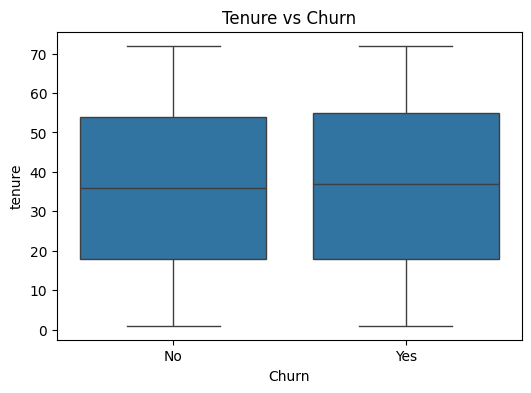

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

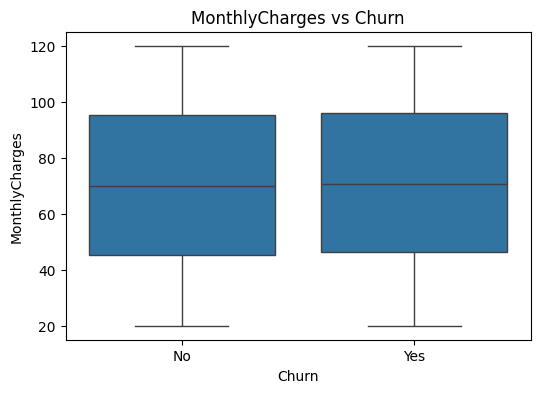

In [ ]:

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("MonthlyCharges vs Churn")
plt.show()

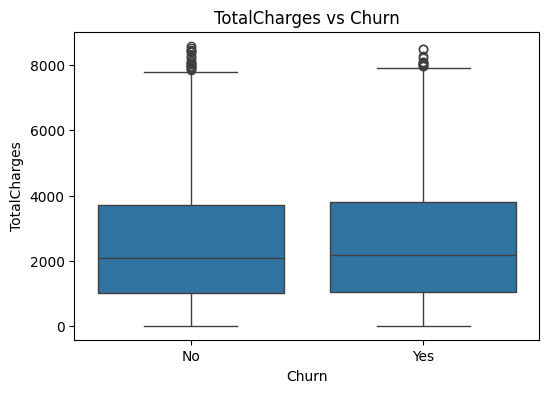

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("TotalCharges vs Churn")
plt.show()

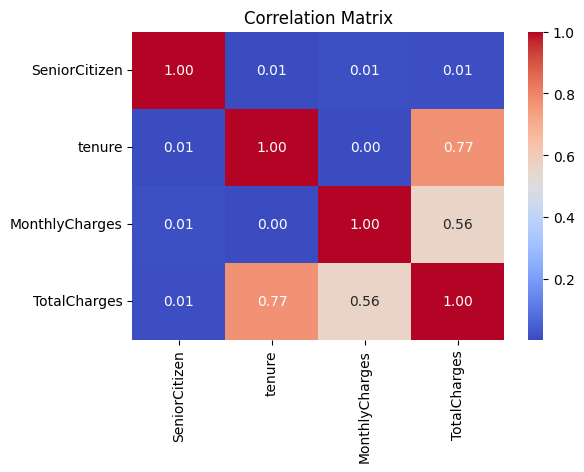

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [9]:
X = df.drop(["Churn", "customerID"], axis=1)

y = df["Churn"]

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [10]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5880, 19)
Target shape: (5880,)


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [11]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,No,Yes,23,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55
1,Female,0,Yes,No,43,No,No phone service,DSL,Yes,No,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10
2,Male,1,No,No,51,Yes,No,DSL,No,Yes,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83
3,Male,1,No,No,72,Yes,Yes,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36
4,Male,1,No,No,25,Yes,Yes,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50


In [12]:
y.head()

,Churn
0,No
1,Yes
2,Yes
3,No
4,Yes


In [ ]:
print(X.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')


In [13]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [14]:
for col in categorical_features:
    print(f"\n{col}:")
    print(X[col].unique())


gender:
['Male' 'Female']

Partner:
['No' 'Yes']

Dependents:
['Yes' 'No']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['No' 'DSL' 'Fiber optic']

OnlineSecurity:
['No internet service' 'Yes' 'No']

OnlineBackup:
['No internet service' 'No' 'Yes']

DeviceProtection:
['No internet service' 'Yes' 'No']

TechSupport:
['No internet service' 'No' 'Yes']

StreamingTV:
['No internet service' 'Yes' 'No']

StreamingMovies:
['No internet service' 'No' 'Yes']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Bank transfer' 'Mailed check' 'Electronic check' 'Credit card']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4704, 19)
X_test: (1176, 19)
y_train: (4704,)
y_test: (1176,)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [30]:
X_train_processed = preprocessor.fit_transform(X_train)

In [31]:
X_test_processed = preprocessor.transform(X_test)

In [32]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (4704, 19)
Processed X_train shape: (4704, 45)
Original X_test shape: (1176, 19)
Processed X_test shape: (1176, 45)


In [33]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

for feature in feature_names:
    print(feature)

Number of features: 45
categorical__gender_Female
categorical__gender_Male
categorical__Partner_No
categorical__Partner_Yes
categorical__Dependents_No
categorical__Dependents_Yes
categorical__PhoneService_No
categorical__PhoneService_Yes
categorical__MultipleLines_No
categorical__MultipleLines_No phone service
categorical__MultipleLines_Yes
categorical__InternetService_DSL
categorical__InternetService_Fiber optic
categorical__InternetService_No
categorical__OnlineSecurity_No
categorical__OnlineSecurity_No internet service
categorical__OnlineSecurity_Yes
categorical__OnlineBackup_No
categorical__OnlineBackup_No internet service
categorical__OnlineBackup_Yes
categorical__DeviceProtection_No
categorical__DeviceProtection_No internet service
categorical__DeviceProtection_Yes
categorical__TechSupport_No
categorical__TechSupport_No internet service
categorical__TechSupport_Yes
categorical__StreamingTV_No
categorical__StreamingTV_No internet service
categorical__StreamingTV_Yes
categorical__S

In [34]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [35]:
print(X_train_processed.shape)

(4704, 45)


In [36]:
print(X_train_processed[:5])

[[ 0.          1.          1.          0.          0.          1.
   0.          1.          0.          0.          1.          0.
   0.          1.          0.          1.          0.          0.
   1.          0.          0.          1.          0.          0.
   1.          0.          0.          1.          0.          0.
   1.          0.          0.          1.          0.          0.
   1.          1.          0.          0.          0.          1.0008507
   0.45335818  0.46968362  0.67420227]
 [ 0.          1.          0.          1.          0.          1.
   1.          0.          0.          1.          0.          1.
   0.          0.          0.          0.          1.          1.
   0.          0.          1.          0.          0.          0.
   0.          1.          0.          0.          1.          0.
   0.          1.          0.          0.          1.          0.
   1.          0.          0.          1.          0.          1.0008507
   0.31023087  0.339389

In [20]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

In [37]:
print(target_encoder.classes_)
print(y_train_encoded[:10])

['No' 'Yes']
[0 1 1 1 0 0 1 0 1 0]


In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_processed, y_train_encoded)

LogisticRegression(max_iter=1000)

In [40]:
y_pred = model.predict(X_test_processed)

In [41]:
print(y_pred[:20])

[0 0 1 1 0 0 1 0 0 1 1 0 1 0 1 0 1 1 0 0]


In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5008503401360545


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

[[357 239]
 [348 232]]


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.60      0.55       596
           1       0.49      0.40      0.44       580

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176



In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train_processed, y_train_encoded)

baseline_pred = baseline_model.predict(X_test_processed)

baseline_accuracy = accuracy_score(
    y_test_encoded,
    baseline_pred
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5068027210884354


In [46]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train_processed,
    y_train_encoded
)

DecisionTreeClassifier(random_state=42)

In [47]:
tree_pred = decision_tree.predict(X_test_processed)

In [48]:
tree_accuracy = accuracy_score(
    y_test_encoded,
    tree_pred
)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.483843537414966


In [49]:
tree_train_pred = decision_tree.predict(X_train_processed)

tree_train_accuracy = accuracy_score(
    y_train_encoded,
    tree_train_pred
)

print("Decision Tree Training Accuracy:", tree_train_accuracy)
print("Decision Tree Test Accuracy:", tree_accuracy)

Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 0.483843537414966


apply random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.4897959183673469

Confusion Matrix:
[[311 285]
 [315 265]]

Classification Report:
              precision    recall  f1-score   support

          No       0.50      0.52      0.51       596
         Yes       0.48      0.46      0.47       580

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176



In [ ]:
train_accuracy_rf = rf_model.score(X_train_processed, y_train)
test_accuracy_rf = rf_model.score(X_test_processed, y_test)

print("Random Forest Training Accuracy:", train_accuracy_rf)
print("Random Forest Test Accuracy:", test_accuracy_rf)

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.4897959183673469


Apply Xbost

In [51]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_processed, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test_processed)

print("XGBoost Training Accuracy:",
      xgb_model.score(X_train_processed, y_train_encoded))

print("XGBoost Test Accuracy:",
      xgb_model.score(X_test_processed, y_test_encoded))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb))

XGBoost Training Accuracy: 0.6475340136054422
XGBoost Test Accuracy: 0.48554421768707484

Confusion Matrix:
[[309 287]
 [318 262]]

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.52      0.51       596
           1       0.48      0.45      0.46       580

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.48      1176
weighted avg       0.49      0.49      0.49      1176



Apply Catbooster

In [52]:
!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [53]:
categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [61]:
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

CatBoostClassifier(depth=5, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

apply WOE

In [6]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,1056,964
One year,968,986
Two year,958,948


In [7]:
contract_crosstab = pd.crosstab(df['Contract'], df['Churn'])

contract_distribution = contract_crosstab.div(
    contract_crosstab.sum(axis=0),
    axis=1
)

contract_distribution

Churn,No,Yes
Contract,,
Month-to-month,0.354125,0.332643
One year,0.324614,0.340235
Two year,0.321261,0.327122


In [8]:
import numpy as np

woe_contract = np.log(
    contract_distribution['No'] /
    contract_distribution['Yes']
)

woe_contract

,0
Contract,
Month-to-month,0.062579
One year,-0.046998
Two year,-0.018080


In [21]:
categorical_columns = X_train.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Feature: {column}")
    print(f"{'='*50}")

    crosstab = pd.crosstab(df[column], df['Churn'])

    distribution = crosstab.div(
        crosstab.sum(axis=0),
        axis=1
    )

    woe = np.log(
        distribution['No'] /
        distribution['Yes']
    )

    print(woe)


Feature: gender
gender
Female    0.016485
Male     -0.016370
dtype: float64

Feature: Partner
Partner
No     0.020657
Yes   -0.019892
dtype: float64

Feature: Dependents
Dependents
No     0.002055
Yes   -0.002146
dtype: float64

Feature: PhoneService
PhoneService
No    -0.036059
Yes    0.036053
dtype: float64

Feature: MultipleLines
MultipleLines
No                  0.034429
No phone service   -0.036059
Yes                 0.037588
dtype: float64

Feature: InternetService
InternetService
DSL            0.010688
Fiber optic    0.005895
No            -0.015759
dtype: float64

Feature: OnlineSecurity
OnlineSecurity
No                    -0.002891
No internet service   -0.015759
Yes                    0.019755
dtype: float64

Feature: OnlineBackup
OnlineBackup
No                     0.033884
No internet service   -0.015759
Yes                   -0.018922
dtype: float64

Feature: DeviceProtection
DeviceProtection
No                     0.049388
No internet service   -0.015759
Yes          

In [22]:
# Calculate the distribution difference
distribution_difference = (
    contract_distribution['No']
    - contract_distribution['Yes']
)

distribution_difference

,0
Contract,
Month-to-month,0.021482
One year,-0.015620
Two year,-0.005861


In [23]:
iv_contribution = (
    distribution_difference * woe_contract
)

iv_contribution

,0
Contract,
Month-to-month,0.001344
One year,0.000734
Two year,0.000106


In [24]:
iv_contract = iv_contribution.sum()

iv_contract

np.float64(0.0021843782236932335)

In [25]:
# Store IV values for all categorical features
iv_results = {}

# Loop through every categorical feature
for column in categorical_columns:

    # Create a crosstab between the feature and target
    crosstab = pd.crosstab(df[column], df['Churn'])

    # Calculate distribution within each target class
    distribution = crosstab.div(
        crosstab.sum(axis=0),
        axis=1
    )

    # Calculate WOE
    woe = np.log(
        distribution['No'] /
        distribution['Yes']
    )

    # Calculate distribution difference
    distribution_difference = (
        distribution['No'] -
        distribution['Yes']
    )

    # Calculate IV contribution for each category
    iv_contribution = (
        distribution_difference * woe
    )

    # Sum all category contributions
    iv = iv_contribution.sum()

    # Store total IV for this feature
    iv_results[column] = iv


# Convert results into a DataFrame
iv_df = pd.DataFrame(
    list(iv_results.items()),
    columns=['Feature', 'IV']
)

# Sort from strongest to weakest
iv_df = iv_df.sort_values(
    by='IV',
    ascending=False
).reset_index(drop=True)

iv_df

,Feature,IV
0,Contract,2.184378e-03
1,MultipleLines,1.301139e-03
2,PhoneService,1.299892e-03
3,DeviceProtection,1.234683e-03
4,TechSupport,1.028044e-03
5,OnlineBackup,5.869306e-04
6,StreamingMovies,5.179842e-04
7,PaymentMethod,4.116589e-04
8,Partner,4.108922e-04
9,gender,2.698579e-04


In [26]:
numerical_columns = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

df.groupby('Churn')[numerical_columns].mean()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,0.503018,36.371898,69.732763,2539.957689
Yes,0.498275,36.731539,70.595114,2594.447060


In [27]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[
        '0-12 months',
        '13-24 months',
        '25-36 months',
        '37-48 months',
        '49-60 months',
        '61-72 months'
    ]
)

pd.crosstab(
    df['tenure_group'],
    df['Churn'],
    normalize='index'
)

Churn,No,Yes
tenure_group,,
0-12 months,0.524440,0.475560
13-24 months,0.503435,0.496565
25-36 months,0.501078,0.498922
37-48 months,0.490073,0.509927
49-60 months,0.524096,0.475904
61-72 months,0.498998,0.501002


In [28]:
df['MonthlyCharges_group'] = pd.qcut(
    df['MonthlyCharges'],
    q=5,
    duplicates='drop'
)

pd.crosstab(
    df['MonthlyCharges_group'],
    df['Churn'],
    normalize='index'
)

Churn,No,Yes
MonthlyCharges_group,,
"(19.999, 40.296]",0.525510,0.474490
"(40.296, 60.406]",0.509354,0.490646
"(60.406, 80.474]",0.493197,0.506803
"(80.474, 100.242]",0.504252,0.495748
"(100.242, 119.99]",0.503401,0.496599


In [56]:
type(X_train_processed)

numpy.ndarray

In [58]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(
    model_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance

NameError: name 'model_xgb' is not defined

In [59]:
preprocessor
model_xgb

NameError: name 'model_xgb' is not defined

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the trained XGBoost model
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
)

# Sort from most important to least important
importance = importance.sort_values(ascending=False)

importance

,0
categorical__StreamingMovies_No,0.045752
categorical__Dependents_No,0.045029
categorical__StreamingTV_No,0.039029
categorical__StreamingMovies_Yes,0.038986
categorical__TechSupport_No,0.038806
categorical__PaymentMethod_Mailed check,0.038123
categorical__MultipleLines_Yes,0.037790
categorical__PhoneService_No,0.037739
categorical__OnlineSecurity_No,0.037177
categorical__StreamingTV_Yes,0.036536
